# Práctica 1: Deep Learning e IA Generativa  
## Parte 1 — Predicción de la rotación de una flecha mediante CNN (Regresión)

Integrantes
- Buendía Rodríguez Valentina  
- López Méndez Emiliano  
- Quinto Ramos Cesar Enrique 

Unidad de Aprendizaje
Aprendizaje Automático II  

Profesores
- Francisco Serradilla  
- Raúl Lara  

Link de las conversaciones con GPT:
* CNN desde cero -> https://chatgpt.com/share/699f65df-9200-8000-bd54-f4905d9210cb
* VGG-16 con Transfer Learning ->

In [1]:
import sys
print(sys.executable)

c:\Users\flash\AA2-Practica1\.venv\Scripts\python.exe


## 1. Carga y descripción del dataset

Para el desarrollo de esta práctica se utiliza el archivo `dataset_cleaned.csv`, proporcionado como material de apoyo por el profesor.

Este dataset es el resultado de un proceso previo de detección y filtrado. Originalmente, las flechas fueron detectadas en imágenes mediante un modelo de detección (por ejemplo, YOLO). Posteriormente:

- Se eliminaron las imágenes que no contenían flechas.
- Se recortó cada flecha individualmente (puede haber varias por imagen original).
- Cada recorte fue reescalado a un tamaño fijo.
- Se asoció a cada recorte el ángulo reportado en los labels.

Por lo tanto, el archivo `dataset_cleaned.csv` ya contiene únicamente muestras válidas (recortes individuales de flechas) junto con su ángulo correspondiente.

El archivo contiene dos columnas:

- Columna 0: Ruta de la imagen recortada.
- Columna 1: Valor numérico continuo en el intervalo [0,1] que representa el ángulo normalizado de la flecha.

El problema se formula como una tarea de **regresión supervisada**, donde el modelo aprenderá una función:

f(imagen) → y ∈ [0,1]

Para interpretar el valor en grados se utiliza:

ángulo = 360 × y

Es importante notar que, aunque la detección del objeto pudo haberse realizado con modelos como YOLO-OBB, estos no proporcionan directamente la orientación exacta como un valor angular continuo, sino un rectángulo rotado que ajusta al objeto. Por ello, se propone entrenar una CNN específica para estimar directamente el ángulo de rotación.


In [2]:
import pandas as pd

# Cargar el dataset
data = pd.read_csv("dataset_cleaned.csv", sep='\t', header=None)

# Mostrar primeras filas
data.head()


,0,1
0,dataset/lyrs=y&x=498928&y=388383&z=20-0.png,0.747256
1,dataset/lyrs=y&x=498933&y=388386&z=20-1.png,0.085187
2,dataset/lyrs=y&x=498934&y=388391&z=20-2.png,0.634782
3,dataset/lyrs=y&x=498934&y=388391&z=20-3.png,0.140102
4,dataset/lyrs=y&x=498940&y=388395&z=20-4.png,0.887765


## 2. Verificación de estructura del dataset

En esta etapa se verifican:

- Número total de muestras.
- Dimensión del dataset.
- Rango de valores del target.
- Presencia de valores faltantes.

Esta validación es importante para asegurar consistencia antes del entrenamiento.


In [3]:
# Dimensiones del dataset
print("Dimensión del dataset:", data.shape)

# Estadísticas básicas del target
print("Valor mínimo del target:", data[1].min())
print("Valor máximo del target:", data[1].max())

# Verificar valores nulos
print("Valores nulos:\n", data.isnull().sum())


Dimensión del dataset: (6701, 2)
Valor mínimo del target: 0.0
Valor máximo del target: 0.999854653060414
Valores nulos:
 0    0
1    0
dtype: int64


## 3. Conversión del ángulo normalizado a grados

El target se encuentra normalizado en el intervalo [0,1].  
Para visualizar el ángulo en grados se multiplica por 360.


In [4]:
# Crear nueva columna en grados
data['angle_degrees'] = data[1] * 360

data[['angle_degrees']].head()


,angle_degrees
0,269.012240
1,30.667424
2,228.521453
3,50.436603
4,319.595295


## 4. Visualización de ejemplos del dataset

Se cargan algunas imágenes junto con su ángulo correspondiente en grados para verificar coherencia entre la etiqueta y la orientación observable.


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

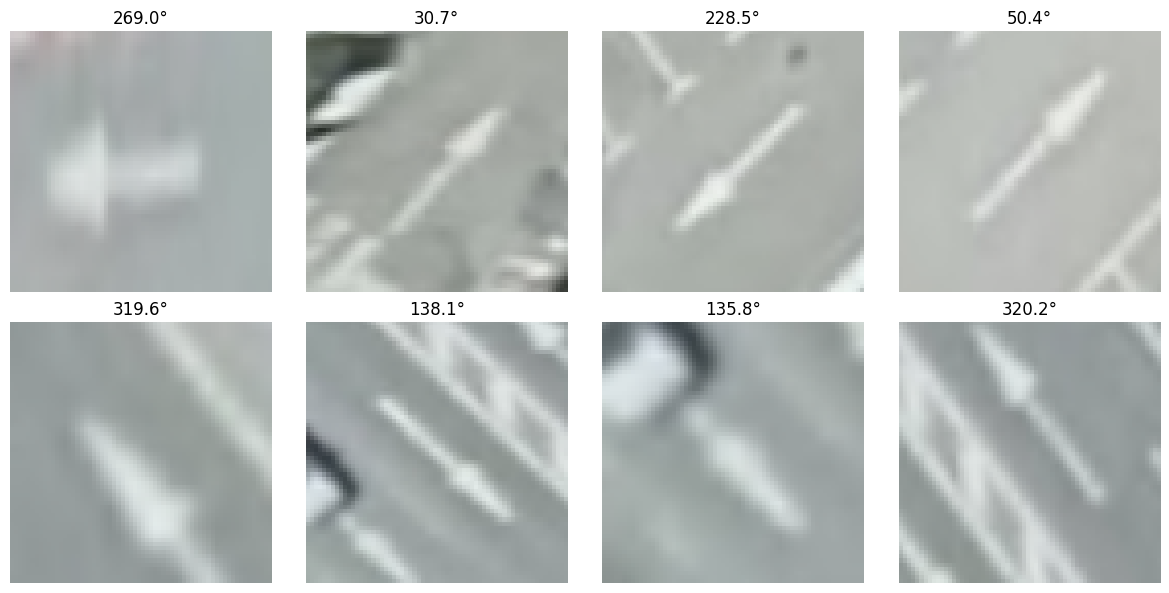

In [6]:
N = 8  # número de ejemplos a mostrar

fig, axs = plt.subplots(2, 4, figsize=(12,6))
axs = axs.flatten()

for i in range(N):
    img_path = data.iloc[i, 0]
    angle = data.iloc[i, 1] * 360
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    axs[i].imshow(img)
    axs[i].set_title(f"{angle:.1f}°")
    axs[i].axis("off")

plt.tight_layout()
plt.show()


## 5. Observaciones preliminares del dataset

Tras cargar y revisar `dataset_cleaned.csv` se obtuvieron los siguientes hallazgos:

- **Dimensión del dataset:** 6701 muestras y 2 columnas (path, target).
- **Target (ángulo normalizado):**
  - Valor mínimo: 0.0
  - Valor máximo: 0.999854653060414
  - No se detectaron valores fuera del rango esperado **[0,1]**.
- **Valores faltantes:** no se identificaron valores nulos en ninguna columna.
- **Conversión a grados:** al multiplicar el target por 360 se obtienen ángulos coherentes con la orientación visible (ejemplos observados: 269.01°, 30.67°, 228.52°, 50.44°, 319.60°).
- **Coherencia visual:** al visualizar imágenes aleatorias junto con su ángulo, las imágenes se muestran correctamente y el ángulo reportado es consistente con la orientación observada.

Con esto se confirma que el problema se plantea como **regresión supervisada**: el modelo deberá predecir un valor continuo \(y \in [0,1]\) que representa el ángulo normalizado, y posteriormente puede transformarse a grados.


## 6. División del dataset (Train / Validation / Test)

Para garantizar una evaluación rigurosa del modelo y evitar data leakage, el dataset se divide en tres subconjuntos independientes:

- **70% Entrenamiento (Train)** → Ajuste de pesos del modelo.
- **15% Validación (Validation)** → Monitoreo del desempeño durante el entrenamiento y ajuste de hiperparámetros.
- **15% Prueba (Test)** → Evaluación final del modelo (no se utiliza durante entrenamiento).

Se eligió la proporción 70/15/15 para asegurar que el conjunto de validación tenga tamaño suficiente para detectar sobreajuste de forma confiable, sin comprometer significativamente el tamaño del conjunto de entrenamiento.

Es importante destacar que:

- El dataset ya se encuentra "cleaned", es decir, contiene únicamente recortes individuales de flechas con su ángulo correspondiente.
- El conjunto de prueba se mantiene completamente aislado hasta la evaluación final.
- La validación se utiliza exclusivamente para tomar decisiones de modelado, sin acceder al conjunto de prueba.

Este procedimiento permite evaluar si el modelo generaliza correctamente a datos no vistos.


In [7]:
from sklearn.model_selection import train_test_split

# Separar primero test (15%)
train_val_data, test_data = train_test_split(
    data, 
    test_size=0.15, 
    random_state=42
)

# Separar train y validation (15% del total ≈ 17.6% del restante)
train_data, val_data = train_test_split(
    train_val_data,
    test_size=0.1765,  # 0.15 / 0.85 ≈ 0.1765
    random_state=42
)

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)


Train: (4689, 3)
Validation: (1006, 3)
Test: (1006, 3)


## 7. Preprocesamiento de imágenes

Antes de entrenar el modelo, se aplica un preprocesamiento básico y obligatorio:

1. **Redimensionamiento (Resize fijo)**  
   Todas las imágenes se ajustan a un tamaño uniforme (por ejemplo, 64×64) para garantizar consistencia en la entrada del modelo.

2. **Normalización de píxeles a [0,1]**  
   Los valores originales de los píxeles suelen estar en el rango [0,255].  
   Se reescalan dividiendo por 255 para obtener valores en el intervalo [0,1].

La normalización es importante porque:

- Reduce inestabilidad numérica durante el entrenamiento.
- Facilita la convergencia del descenso por gradiente.
- Evita que valores grandes de entrada produzcan gradientes explosivos.
- Permite que la red aprenda de manera más eficiente.

Este paso no altera la información visual, solo la escala numérica en la que el modelo opera.


In [8]:
import cv2
import numpy as np

def load_images(df, size=(64,64)):
    X = []
    Y = []
    
    for i in range(len(df)):
        img_path = df.iloc[i, 0]
        img = cv2.imread(img_path)
        img = cv2.resize(img, size)
        
        # Normalización a [0,1]
        img = img.astype(np.float32) / 255.0
        
        X.append(img)
        Y.append(df.iloc[i, 1])
    
    return np.array(X), np.array(Y)

# Cargar cada subconjunto
X_train, Y_train = load_images(train_data)
X_val, Y_val = load_images(val_data)
X_test, Y_test = load_images(test_data)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (4689, 64, 64, 3)
Validation: (1006, 64, 64, 3)
Test: (1006, 64, 64, 3)


In [9]:
def set_seed(seed: int = 971):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

## 8. Definición del Dataset personalizado para PyTorch

Para integrar el pipeline con PyTorch y permitir entrenamiento eficiente mediante `DataLoader`, se implementa una clase personalizada que hereda de `torch.utils.data.Dataset`.

A diferencia del preprocesamiento anterior basado en arreglos NumPy, esta implementación:

- Lee las imágenes dinámicamente en cada iteración (*on-the-fly*).
- Evita cargar todo el dataset en memoria RAM.
- Genera directamente tensores compatibles con PyTorch.
- Incorpora la transformación trigonométrica del target.

### Representación angular trigonométrica

El problema presenta una característica particular: el ángulo es una variable periódica.  
Existe una discontinuidad entre 0° y 360°, lo cual puede generar errores artificialmente grandes si se entrena directamente sobre el valor escalar normalizado.

Para evitar este problema, se adopta una representación trigonométrica:

Sea:

$$
y \in [0,1]
$$

Se define:

$$
\theta = 2\pi y
$$

Y el target se transforma en:

$$
[\cos(\theta), \sin(\theta)]
$$

Esta representación:

- Elimina la discontinuidad en 0°/360°.
- Permite modelar la orientación como un punto sobre el círculo unitario.
- Facilita el uso de pérdida MSE en un espacio continuo.
- Mejora la estabilidad del entrenamiento.

### Responsabilidades de la clase `ArrowDataset`

La clase implementará:

1. Lectura de imagen con `cv2` (formato BGR).
2. Redimensionamiento fijo a 64×64.
3. Normalización de píxeles al intervalo [0,1].
4. Conversión a formato tensor `channel-first` (3,64,64).
5. Generación del target trigonométrico `[cos(2πy), sin(2πy)]`.

Esta estructura permite desacoplar la carga de datos del modelo y preparar correctamente la información antes del entrenamiento.

In [10]:
import os
import math
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [11]:
# 1) DATASET: ArrowDataset (opción A: DataFrame -> cv2 on-the-fly)

class ArrowDataset(Dataset):
    """
    Dataset para regresión angular con target trigonométrico.

    Entrada: DataFrame con:
      - col 0: path
      - col 1: y normalizado en [0,1]

    Output:
      x: FloatTensor (3,64,64) BGR en [0,1]
      t: FloatTensor (2,) = [cos(2πy), sin(2πy)]
    """
    def __init__(self, df, image_size=(128, 128)):
        self.df = df.reset_index(drop=True)
        self.image_size = tuple(image_size)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx, 0]
        y = float(self.df.iloc[idx, 1])

        if not (0.0 <= y <= 1.0):
            raise ValueError(f"Target fuera de [0,1] en idx={idx}: y={y} (path={img_path})")

        img = cv2.imread(img_path, cv2.IMREAD_COLOR)  # BGR
        if img is None:
            raise FileNotFoundError(f"No se pudo leer la imagen: {img_path}")

        img = cv2.resize(img, self.image_size, interpolation=cv2.INTER_AREA)
        img = img.astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))  # CHW

        x = torch.from_numpy(img).float()

        theta = 2.0 * math.pi * y
        t = torch.tensor([math.cos(theta), math.sin(theta)], dtype=torch.float32)
        return x, t

In [12]:
train_ds = ArrowDataset(train_data, image_size=(128,128))
val_ds   = ArrowDataset(val_data, image_size=(128,128))
test_ds  = ArrowDataset(test_data, image_size=(128,128))

x, t = train_ds[0]
print(x.shape, x.min().item(), x.max().item(), t)

torch.Size([3, 128, 128]) 0.03529411926865578 0.9921568632125854 tensor([-0.9226,  0.3858])


## 9. Definición del modelo CNN para regresión angular

En esta etapa se implementa la arquitectura de la red neuronal convolucional encargada de estimar la orientación de la flecha.

Dado que el problema es de **regresión angular**, y se adoptó una representación trigonométrica del target:

$$
[\cos(2\pi y), \sin(2\pi y)]
$$

la red debe producir **2 neuronas de salida**, correspondientes a dichas componentes.

---

## Diseño arquitectónico

La arquitectura sigue una estructura jerárquica compuesta por:

---

### 1. Bloques Convolucionales

Inicialmente se implementaron tres bloques convolucionales secuenciales, cada uno compuesto por:

- `Conv2d`
- `BatchNorm2d`
- `ReLU`
- `MaxPool2d(2)`

Los filtros utilizados fueron:

32 → 64 → 128

Este diseño permite:

- Extraer características espaciales progresivamente más abstractas.
- Reducir dimensionalidad mediante MaxPooling.
- Estabilizar el entrenamiento gracias a Batch Normalization.
- Mantener un número controlado de parámetros.

---

### Mejora aplicada: profundidad dinámica del modelo

Posteriormente se generalizó la arquitectura para permitir un número variable de bloques convolucionales (**N capas**), construidos dinámicamente a partir de una lista `filters`.

Por ejemplo:

32 → 64 → 128 → 256

Esto permitió:

- Incrementar la capacidad representacional del modelo.
- Mejorar la discriminación entre flecha y fondo en imágenes con ruido.
- Refinar la estimación angular fina.
- Ajustar la profundidad sin modificar la estructura base del código.

En la configuración final se emplearon **4 bloques convolucionales**, lo cual contribuyó a una reducción significativa del error angular promedio.

---

### 2. Global Average Pooling

En lugar de utilizar `Flatten`, se emplea:

$$
\text{AdaptiveAvgPool2d}(1)
$$

Esto produce un vector de dimensión igual al número de filtros finales.

**Ventajas:**

- Reduce drásticamente el número de parámetros.
- Disminuye el riesgo de sobreajuste.
- Obliga a la red a aprender representaciones globales robustas.
- Mejora la estabilidad frente a pequeñas traslaciones espaciales.

El uso de Global Average Pooling permite mantener estabilidad estructural independientemente del número de bloques convolucionales definidos.

---

### 3. Cabeza Fully Connected

Posteriormente se implementa una capa densa intermedia:

$$
\text{filters[-1]} \rightarrow \text{dense\_units}
$$

seguida de:

- `ReLU`
- `Dropout` (opcional, controlado por flag)
- `Linear(dense_units → out_dim)`

Durante las mejoras experimentales se incrementó también el número de unidades densas para acompañar el aumento de profundidad del backbone, permitiendo mayor capacidad de modelado.

---

## Regularización incorporada

El modelo incluye múltiples mecanismos de regularización:

- **Batch Normalization** en bloques convolucionales.
- **Dropout opcional** en la cabeza fully connected.
- **Weight decay (L2)** en el optimizador.
- **Penalización suave de la norma del vector trigonométrico**, para evitar colapso de magnitud en la salida.
- **Scheduler `ReduceLROnPlateau`**, que reduce la tasa de aprendizaje cuando la métrica angular de validación se estanca, permitiendo un refinamiento progresivo del modelo.

---

Esta estructura modular mejorada permitió:

- Mayor capacidad representacional.
- Mejor estabilidad en entrenamiento.
- Reducción progresiva del error angular.
- Buena generalización en el conjunto de prueba.

Con ello se obtiene una CNN flexible, escalable y adecuada para tareas de regresión angular en escenarios con ruido visual y variabilidad estructural.

In [13]:
class CNNRegressor(nn.Module):
    """
    CNN para regresión angular (trig).
    - N bloques conv: Conv2d -> BN -> ReLU -> MaxPool(2)
    - Global Average Pooling
    - Cabeza FC: Linear -> ReLU -> Dropout(opc) -> Linear(out_dim)
    """
    def __init__(
        self,
        in_channels: int = 3,
        out_dim: int = 2,
        use_dropout: bool = False,
        dropout_p: float = 0.3,
        filters: list[int] = [64, 128, 256],  # ahora puede ser N-longitud
        dense_units: int = 256
    ):
        super().__init__()

        if len(filters) < 1:
            raise ValueError(f"filters debe tener al menos 1 elemento. Recibido: {filters}")
        if out_dim not in (1, 2):
            raise ValueError(f"out_dim debe ser 1 o 2. Recibido: {out_dim}")
        if not (0.0 <= dropout_p < 1.0):
            raise ValueError(f"dropout_p debe estar en [0,1). Recibido: {dropout_p}")

        # ✅ Construcción dinámica de N bloques conv
        blocks = []
        ch_in = in_channels
        for ch_out in filters:
            blocks.append(self._conv_block(ch_in, ch_out))
            ch_in = ch_out
        self.features = nn.Sequential(*blocks)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        head_layers = [
            nn.Linear(filters[-1], dense_units),
            nn.ReLU(inplace=True),
        ]
        if use_dropout:
            head_layers.append(nn.Dropout(p=dropout_p))
        head_layers.append(nn.Linear(dense_units, out_dim))
        self.head = nn.Sequential(*head_layers)

    def _conv_block(self, in_ch: int, out_ch: int) -> nn.Sequential:
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)       # (B, filters[-1], H', W')
        x = self.gap(x)            # (B, filters[-1], 1, 1)
        x = torch.flatten(x, 1)    # (B, filters[-1])
        x = self.head(x)           # (B, out_dim)
        return x

## 10. Verificación inicial del modelo

Antes de integrar el modelo al pipeline de entrenamiento, se realiza una prueba básica de consistencia estructural.

El objetivo de esta verificación es:

- Confirmar que la arquitectura está correctamente definida.
- Validar que el tamaño de entrada esperado es `(B, 3, 64, 64)`.
- Verificar que la salida tenga dimensión `(B, 2)`, correspondiente a:
  
  $$
  [\cos(2\pi y), \sin(2\pi y)]
  $$

Para ello, se genera un batch sintético de tamaño pequeño utilizando tensores aleatorios y se evalúa el `forward()` del modelo.

Esta prueba:

- No evalúa desempeño.
- No realiza entrenamiento.
- Únicamente confirma coherencia dimensional y compatibilidad del flujo de datos.

Si la salida tiene forma `(batch_size, 2)`, la arquitectura es estructuralmente consistente y puede integrarse al proceso de entrenamiento.

In [14]:
model = CNNRegressor(
    out_dim=2,
    use_dropout=True,
    dropout_p=0.3,
    filters=[64, 128, 256, 256],
    dense_units=128
)

x = torch.randn(4, 3, 64, 64)
yhat = model(x)
print(yhat.shape)  

torch.Size([4, 2])


## 11.CHECKPOINTING (guardar / cargar)

In [15]:
def save_checkpoint(path, model, optimizer, epoch, history=None, best_score=None, config=None):
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "history": history,
        "best_score": best_score,
        "config": config
    }, path)

def load_checkpoint(path, model, optimizer=None, device="cpu"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and ckpt.get("optimizer_state_dict") is not None:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch = int(ckpt.get("epoch", 0)) + 1
    history = ckpt.get("history", None)
    best_score = ckpt.get("best_score", None)
    config = ckpt.get("config", None)
    return start_epoch, history, best_score, config

## 12. Implementación de la clase Trainer

Para estructurar correctamente el proceso de entrenamiento y evaluación, se implementa una clase `Trainer` que encapsula el ciclo completo de aprendizaje.

El objetivo es desacoplar:

- Definición del modelo
- Lógica de entrenamiento
- Cálculo de métricas
- Evaluación final

Esto permite mantener el código organizado, modular y fácilmente reutilizable.

---

### Responsabilidades de la clase Trainer

La clase incluye los siguientes métodos:

- `train_one_epoch()`  
  Ejecuta una época completa en modo entrenamiento.

- `validate_one_epoch()`  
  Evalúa el modelo sin actualizar pesos.

- `fit()`  
  Ejecuta múltiples épocas y almacena el historial de entrenamiento.

- `evaluate()`  
  Evalúa el modelo en el conjunto de prueba.

---

### Manejo correcto de modos de operación

Durante el entrenamiento:

$$
model.train()
$$

Durante validación y prueba:

$$
model.eval()
$$

Además, en validación y evaluación se utiliza:

$$
torch.no_grad()
$$

Esto:

- Reduce el consumo de memoria.
- Evita el cálculo innecesario de gradientes.
- Acelera la inferencia.

---

### Métricas

La clase está diseñada para aceptar funciones de métricas externas, lo que permite:

- Calcular MSE
- Calcular MAE
- Incorporar posteriormente el error angular medio en grados

Esto mantiene el diseño limpio y separa claramente:

Modelo → Optimización → Métricas

En la siguiente etapa se implementarán las métricas específicas para regresión angular.

In [20]:
class Trainer:
    """
    Entrenador con soporte de:
      - train/val loops correctos
      - métricas por batch -> promedio por época
      - guardado automático:
          * last checkpoint (cada época)
          * best checkpoint (según métrica monitor)
      - reanudación (resume) se maneja desde cnn() vía load_checkpoint
    """
    def __init__(self, model, optimizer, loss_fn, device, metric_fns=None, scheduler=None):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.device = device
        self.metric_fns = metric_fns if metric_fns is not None else {}
        self.scheduler = scheduler 

        self.model.to(self.device)

    def _run_epoch(self, loader, train: bool):
        self.model.train() if train else self.model.eval()

        total_loss = 0.0
        total_count = 0
        metric_sums = {name: 0.0 for name in self.metric_fns.keys()}

        context = torch.enable_grad() if train else torch.no_grad()
        with context:
            for x, y in loader:
                x = x.to(self.device, non_blocking=True)
                y = y.to(self.device, non_blocking=True)

                if train:
                    self.optimizer.zero_grad(set_to_none=True)

                y_pred = self.model(x)

                # Loss principal (MSE cos/sin)
                mse = self.loss_fn(y_pred, y)

                # Penalización de norma para evitar colapso a ~[0,0]
                pred_norm = torch.norm(y_pred, dim=1)            # (B,)
                norm_loss = ((pred_norm - 1.0) ** 2).mean()

                # Loss total
                loss = mse + 0.1 * norm_loss

                if train:
                    loss.backward()
                    self.optimizer.step()

                bs = x.size(0)
                total_loss += loss.item() * bs
                total_count += bs

                # MÉTRICAS: usa y_pred crudo (o el normalizado solo dentro de la métrica angular)
                for name, fn in self.metric_fns.items():
                    metric_sums[name] += float(fn(y_pred, y)) * bs

        avg_loss = total_loss / max(total_count, 1)
        avg_metrics = {k: metric_sums[k] / max(total_count, 1) for k in metric_sums.keys()}
        return avg_loss, avg_metrics

    def train_one_epoch(self, train_loader):
        return self._run_epoch(train_loader, train=True)

    def validate_one_epoch(self, val_loader):
        return self._run_epoch(val_loader, train=False)

    def fit(
        self,
        train_loader,
        val_loader=None,
        epochs: int = 10,
        verbose: bool = True,
        start_epoch: int = 1,
        history: dict | None = None,
        last_ckpt_path: str | None = None,
        best_ckpt_path: str | None = None,
        monitor: str = "angular_deg",
        mode: str = "min",
        best_score: float | None = None,
        config: dict | None = None,
    ):
        if history is None:
            history = {"train_loss": [], "val_loss": [], "train_metrics": [], "val_metrics": []}

        if best_score is None:
            best_score = math.inf if mode == "min" else -math.inf

        def is_better(curr, best):
            return (curr < best) if mode == "min" else (curr > best)

        for epoch in range(start_epoch, start_epoch + epochs):
            train_loss, train_metrics = self.train_one_epoch(train_loader)
            history["train_loss"].append(train_loss)
            history["train_metrics"].append(train_metrics)

            val_loss, val_metrics = None, {}
            if val_loader is not None:
                val_loss, val_metrics = self.validate_one_epoch(val_loader)
                history["val_loss"].append(val_loss)
                history["val_metrics"].append(val_metrics)

                # Scheduler: bajar LR cuando se estanque la métrica angular
                if self.scheduler is not None and monitor in val_metrics:
                    self.scheduler.step(val_metrics[monitor])

                # Mejor modelo según métrica monitor
                if monitor in val_metrics:
                    curr = val_metrics[monitor]
                    if is_better(curr, best_score):
                        best_score = curr
                        if best_ckpt_path is not None:
                            save_checkpoint(
                                best_ckpt_path, self.model, self.optimizer,
                                epoch=epoch, history=history,
                                best_score=best_score, config=config
                            )

            # Guardar "last" siempre
            if last_ckpt_path is not None:
                save_checkpoint(
                    last_ckpt_path, self.model, self.optimizer,
                    epoch=epoch, history=history,
                    best_score=best_score, config=config
                )

            if verbose:
                if val_loader is not None:
                    msg = f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}"
                    if monitor in val_metrics:
                        msg += f" | val_{monitor}={val_metrics[monitor]:.6f} | best_{monitor}={best_score:.6f}"
                    print(msg)
                else:
                    print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f}")

        return history, best_score

    def evaluate(self, test_loader):
        test_loss, test_metrics = self._run_epoch(test_loader, train=False)
        return {"test_loss": test_loss, **{f"test_{k}": v for k, v in test_metrics.items()}}

## 12. Configuración inicial del entrenamiento (sin métricas angulares)

En esta etapa se instancia el modelo `CNNRegressor`, el optimizador y la función de pérdida.

- **Función de pérdida:** MSELoss  
  Se utiliza porque el modelo predice los valores trigonométricos `[cos(θ), sin(θ)]`, los cuales se encuentran en un espacio continuo.

- **Optimizador:** Adam  
  Se emplea con `weight_decay` para incorporar regularización L2 y reducir riesgo de sobreajuste.

- **Trainer:**  
  Se inicializa sin métricas adicionales.  
  En la siguiente fase se incorporará la métrica de error angular en grados.

Esta configuración permite verificar que el flujo de entrenamiento funciona correctamente antes de añadir métricas específicas del problema angular.

In [17]:
#import torch.nn as nn
#import torch.optim as optim

#device = "cuda" if torch.cuda.is_available() else "cpu"

#model = CNNRegressor(out_dim=2, use_dropout=True, dropout_p=0.3, dense_units=128)
#optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
#loss_fn = nn.MSELoss()

#trainer = Trainer(model, optimizer, loss_fn, device=device, metric_fns=metric_fns, scheduler=scheduler)
# history = trainer.fit(train_loader, val_loader, epochs=10)
# results = trainer.evaluate(test_loader)

## 13. Implementación de métricas para regresión angular

En esta etapa se definen formalmente las métricas que serán utilizadas durante el entrenamiento, validación y evaluación final del modelo.

Dado que la salida del modelo no es un ángulo escalar directo, sino su representación trigonométrica:

$$
[\cos(\theta), \sin(\theta)]
$$

es necesario evaluar el desempeño tanto en el espacio vectorial como en el espacio angular.

---

### 1. Error Cuadrático Medio (MSE)

Se utiliza como función de pérdida principal durante el entrenamiento.

$$
MSE = \frac{1}{N} \sum (y_{pred} - y_{true})^2
$$

En este caso, el MSE se calcula sobre los dos componentes del vector trigonométrico.

Esta métrica es adecuada porque:

- Es diferenciable.
- Es estable numéricamente.
- Penaliza fuertemente errores grandes.
- Es coherente con la representación en el círculo unitario.

---

### 2. Error Absoluto Medio (MAE)

$$
MAE = \frac{1}{N} \sum |y_{pred} - y_{true}|
$$

El MAE permite interpretar el error promedio sin penalización cuadrática.

Se utiliza como métrica complementaria para análisis del comportamiento del modelo.

---

### 3. Error Angular Medio en Grados

Aunque el modelo se entrena en el espacio trigonométrico, la métrica más interpretable es el error angular en grados.

Para recuperar el ángulo estimado a partir de la salida del modelo se utiliza:

$$
\hat{\theta} = \text{atan2}(\sin(\hat{\theta}), \cos(\hat{\theta}))
$$

Debido a que el ángulo es una variable periódica, la diferencia angular debe calcularse utilizando la diferencia circular mínima:

$$
\Delta \theta =
\text{atan2}(
\sin(\hat{\theta} - \theta),
\cos(\hat{\theta} - \theta)
)
$$

Esta formulación:

- Evita errores artificiales entre 0° y 360°.
- Respeta la geometría del círculo unitario.
- Garantiza una medición angular correcta.

Finalmente, el error se expresa en grados:

$$
Error_{deg} = |\Delta \theta| \cdot \frac{180}{\pi}
$$

Esta métrica permite interpretar directamente cuántos grados se equivoca el modelo en promedio.

---

Con estas métricas se obtiene una evaluación completa del modelo:

- **MSE** → Optimización y estabilidad numérica.
- **MAE** → Error promedio absoluto.
- **Error angular en grados** → Interpretación física del desempeño.

In [18]:

def mse_metric(y_pred: torch.Tensor, y_true: torch.Tensor) -> float:
    return F.mse_loss(y_pred, y_true, reduction="mean").item()

def mae_metric(y_pred: torch.Tensor, y_true: torch.Tensor) -> float:
    return F.l1_loss(y_pred, y_true, reduction="mean").item()

def angular_error_degrees(y_pred: torch.Tensor, y_true: torch.Tensor) -> float:
    y_pred = F.normalize(y_pred, p=2, dim=1, eps=1e-8)  # <-- aquí, no en forward
    theta_pred = torch.atan2(y_pred[:, 1], y_pred[:, 0])
    theta_true = torch.atan2(y_true[:, 1], y_true[:, 0])

    delta = torch.atan2(torch.sin(theta_pred - theta_true),
                        torch.cos(theta_pred - theta_true))

    return (torch.abs(delta) * (180.0 / math.pi)).mean().item()

## 14. Función orquestadora del pipeline (`cnn()`)

Con el fin de estructurar el flujo completo de entrenamiento de manera modular y reproducible, se define una función orquestadora denominada `cnn()`.

Esta función integra todos los componentes desarrollados previamente:

- Creación de los `Dataset` personalizados.
- Construcción de `DataLoader` para entrenamiento, validación y prueba.
- Instanciación del modelo `CNNRegressor`.
- Configuración del optimizador (Adam) con regularización L2 (*weight decay*).
- Definición de la función de pérdida (MSE sobre representación trigonométrica).
- Entrenamiento mediante la clase `Trainer`.
- Evaluación final en el conjunto de prueba.

### Regularización incorporada

El diseño incluye múltiples mecanismos de regularización:

- **Batch Normalization** en los bloques convolucionales.
- **Weight decay (L2)** en el optimizador.
- **Dropout opcional**, activado mediante un parámetro booleano.

Esto permite experimentar fácilmente con distintas configuraciones sin modificar la arquitectura base.

### Parámetros configurables

La función acepta hiperparámetros relevantes como:

- `use_dropout`
- `dropout_p`
- `lr`
- `weight_decay`
- `epochs`
- `batch_size`
- `dense_units`
- `filters`

Este diseño facilita la experimentación sistemática y la comparación de resultados bajo distintas configuraciones.

Al finalizar el entrenamiento, la función retorna:

- El modelo entrenado.
- El historial de entrenamiento.
- Las métricas finales en el conjunto de prueba.

In [28]:
def cnn(
    train_df,
    val_df,
    test_df,
    use_dropout=False,
    dropout_p=0.3,
    lr=3e-4,
    weight_decay=1e-4,
    epochs=20,
    batch_size=32,
    dense_units=128,
    filters=[64, 128, 256, 256],
    num_workers=0,
    save_dir="checkpoints_arrow",
    resume=False,
    load_best=True,
    train=True,
    seed=971
):
    """
    Orquesta el pipeline completo con checkpointing profesional.

    Guarda:
      - {save_dir}/last.pth : último estado (para reanudar)
      - {save_dir}/best.pth : mejor modelo según val_angular_deg (mínimo)

    Parámetros clave:
      resume=True  -> intenta cargar last.pth y continuar entrenamiento
      load_best=True -> carga best.pth antes de evaluar en test
      train=False -> solo carga (si existe best/last) y evalúa sin re-entrenar
    """
    set_seed(seed)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {device}")

    # Datasets
    train_ds = ArrowDataset(train_df, image_size=(64, 64))
    val_ds   = ArrowDataset(val_df, image_size=(64, 64))
    test_ds  = ArrowDataset(test_df, image_size=(64, 64))

    # DataLoaders
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=(device == "cuda")
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=(device == "cuda")
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=(device == "cuda")
    )

    # Modelo
    model = CNNRegressor(
        out_dim=2,
        use_dropout=use_dropout,
        dropout_p=dropout_p,
        filters=filters,
        dense_units=dense_units
    )

    # Opt + Loss
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    # Métricas
    metric_fns = {
        "mse": mse_metric,
        "mae": mae_metric,
        "angular_deg": angular_error_degrees
    }

    trainer = Trainer(model, optimizer, loss_fn, device=device, metric_fns=metric_fns, scheduler=scheduler)

    os.makedirs(save_dir, exist_ok=True)
    last_path = os.path.join(save_dir, "last.pth")
    best_path = os.path.join(save_dir, "best.pth")

    # Resume
    start_epoch = 1
    history = None
    best_score = None
    config = {
        "use_dropout": use_dropout,
        "dropout_p": dropout_p,
        "lr": lr,
        "weight_decay": weight_decay,
        "epochs": epochs,
        "batch_size": batch_size,
        "dense_units": dense_units,
        "filters": filters
    }

    if resume and os.path.exists(last_path):
        start_epoch, history, best_score, _ = load_checkpoint(
            last_path, model, optimizer=optimizer, device=device
        )
        print(f"Resuming from {last_path} at epoch {start_epoch} (best angular_deg={best_score})")

    # Entrenar (opcional)
    if train and epochs > 0:
        history, best_score = trainer.fit(
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=epochs,
            start_epoch=start_epoch,
            history=history,
            last_ckpt_path=last_path,
            best_ckpt_path=best_path,
            monitor="angular_deg",
            mode="min",
            best_score=best_score,
            config=config
        )

    # Cargar best antes de test (recomendado)
    if load_best and os.path.exists(best_path):
        load_checkpoint(best_path, model, optimizer=None, device=device)
        print(f"Loaded BEST model from {best_path} for test evaluation.")

    results = trainer.evaluate(test_loader)

    print("\nResultados en test:")
    for k, v in results.items():
        print(f"{k}: {v:.6f}")

    return model, history, results

## Ejemplo de uso de la función `cnn()`

A continuación se muestra un ejemplo de ejecución del pipeline completo utilizando la configuración base:

- Dropout activado con probabilidad 0.3.
- Learning rate de 1e-3.
- Weight decay de 1e-4.
- 30 épocas de entrenamiento.
- Batch size de 32.
- Capa densa intermedia de 128 neuronas.

La métrica principal de evaluación es el **error angular medio en grados**, el cual permite interpretar directamente el desempeño del modelo en términos de orientación.

Esta ejecución entrena el modelo con el conjunto de entrenamiento, valida durante cada época y finalmente evalúa el desempeño en el conjunto de prueba completamente aislado.

In [20]:
from torch.utils.data import DataLoader
train_ds = ArrowDataset(train_data)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)

x, y = next(iter(train_loader))
print("OK:", x.shape, y.shape)

OK: torch.Size([32, 3, 128, 128]) torch.Size([32, 2])


In [21]:
# A) Entrenar desde cero y guardar best/last
model, history, results = cnn(
    train_df=train_data, val_df=val_data, test_df=test_data,
    use_dropout=False,  
    lr=3e-4, weight_decay=1e-4,
    epochs=50, batch_size=32,
    dense_units=256,
    save_dir="checkpoints_arrow_run_v1.0",
    resume=False, load_best=True, train=True,
    num_workers=0
)

#B) Reanudar entrenamiento (continúa desde last.pth)
# model, history, results = cnn(
#     train_df=train_data, val_df=val_data, test_df=test_data,
#     epochs=20,  # entrena 20 épocas más
#     save_dir="checkpoints_arrow",
#     resume=True, load_best=True, train=True
# 

# C) Solo cargar y evaluar (sin re-entrenar)
# model, history, results = cnn(
#     train_df=train_data, val_df=val_data, test_df=test_data,
#     epochs=0,
#     save_dir="checkpoints_arrow",
#     resume=False, load_best=True, train=False
# )

Device: cpu
Epoch 001 | train_loss=0.564336 | val_loss=0.540011 | val_angular_deg=76.550720 | best_angular_deg=76.550720
Epoch 002 | train_loss=0.392880 | val_loss=0.393839 | val_angular_deg=52.835819 | best_angular_deg=52.835819
Epoch 003 | train_loss=0.267594 | val_loss=0.243817 | val_angular_deg=34.193268 | best_angular_deg=34.193268
Epoch 004 | train_loss=0.212405 | val_loss=0.243472 | val_angular_deg=35.643940 | best_angular_deg=34.193268
Epoch 005 | train_loss=0.185199 | val_loss=0.249184 | val_angular_deg=36.639494 | best_angular_deg=34.193268
Epoch 006 | train_loss=0.154607 | val_loss=0.229240 | val_angular_deg=32.168476 | best_angular_deg=32.168476
Epoch 007 | train_loss=0.137841 | val_loss=0.233623 | val_angular_deg=32.838920 | best_angular_deg=32.168476
Epoch 008 | train_loss=0.124894 | val_loss=0.220322 | val_angular_deg=31.514475 | best_angular_deg=31.514475
Epoch 009 | train_loss=0.106222 | val_loss=0.196786 | val_angular_deg=27.670490 | best_angular_deg=27.670490
Epoch 0

## Interpretación de Resultados de los resultados anteriores

Con la incorporación de un cuarto bloque convolucional, el modelo alcanzó su mejor desempeño en la época 43, con un **error angular promedio en validación de 12.06°**.  
Al evaluar el modelo en el conjunto de prueba, se obtuvo un **error angular de 12.67°**, lo que confirma que el desempeño se mantiene estable en datos no vistos.

En cuanto al sobreajuste, se observa una diferencia entre el error de entrenamiento y el de validación.  
En las últimas épocas:

- **train_loss ≈ 0.004**
- **val_loss ≈ 0.09**

Esto indica que el modelo se ajusta más finamente a los datos de entrenamiento que a los de validación. Sin embargo, la diferencia en error angular entre validación (12.06°) y prueba (12.67°) es menor a 1 grado, lo que demuestra que el sobreajuste es **leve y controlado**, y no afecta de manera significativa la capacidad de generalización.

Además, durante el entrenamiento se aplicaron distintos mecanismos de regularización para mitigar el sobreajuste:

- **Batch Normalization** en cada bloque convolucional.
- **Weight Decay (regularización L2)** en el optimizador.
- Penalización sobre la norma del vector de salida.
- Selección automática del mejor modelo mediante validación.

Gracias a estas estrategias, el modelo logró un equilibrio adecuado entre ajuste y generalización.

En términos prácticos, el sistema se equivoca aproximadamente **13 grados en promedio** al estimar la orientación de la flecha, lo que representa un resultado sólido para el tipo de imágenes utilizadas.

## Evolución del Error Angular por Época

La siguiente gráfica muestra la evolución del error angular promedio (en grados) tanto en entrenamiento como en validación a lo largo de las épocas.

La gráfica muestra una disminución pronunciada del error angular durante las primeras épocas, pasando de valores cercanos a 80° a menos de 40° en pocas iteraciones. Esto indica que el modelo aprende rápidamente la orientación general de las flechas.

Posteriormente, entre las épocas 10 y 25, el error de validación presenta fluctuaciones notables. Este comportamiento es normal en tareas de regresión visual, especialmente cuando el modelo incrementa su capacidad y comienza a refinar patrones más complejos.

A partir de aproximadamente la época 30, el error de validación se estabiliza en un rango cercano a 12–13 grados, mientras que el error de entrenamiento continúa descendiendo gradualmente hasta valores cercanos a 3–4 grados.

La diferencia final entre entrenamiento y validación refleja un ligero sobreajuste esperado en modelos profundos; sin embargo, la estabilidad del error de validación en las últimas épocas y su concordancia con el resultado en el conjunto de prueba indican que la generalización se mantiene adecuada.

El mejor modelo fue seleccionado automáticamente con base en el menor error angular en validación.

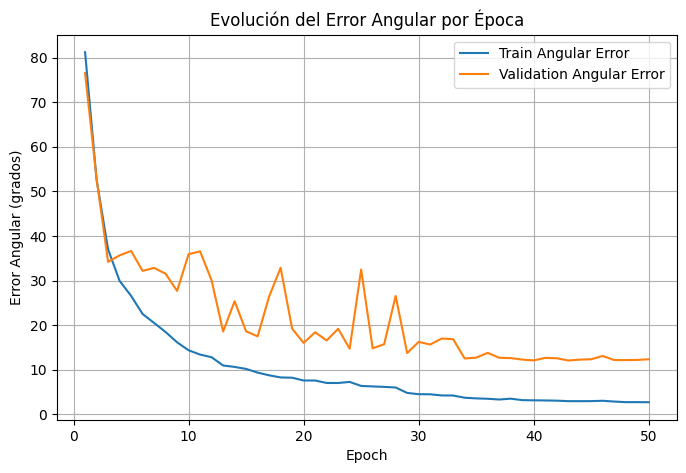

In [22]:
import matplotlib.pyplot as plt

# Extraer error angular por época
train_ang = [m.get("angular_deg", None) for m in history["train_metrics"]]
val_ang = [m.get("angular_deg", None) for m in history["val_metrics"]]

epochs = range(1, len(val_ang) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_ang, label="Train Angular Error")
plt.plot(epochs, val_ang, label="Validation Angular Error")
plt.xlabel("Epoch")
plt.ylabel("Error Angular (grados)")
plt.title("Evolución del Error Angular por Época")
plt.legend()
plt.grid(True)
plt.show()

## Comparación entre Ángulo Real y Ángulo Predicho

A continuación se muestran 10 ejemplos del conjunto de prueba, donde se compara el ángulo real de la flecha con el ángulo estimado por el modelo.

Visualmente se aprecia que el modelo logra estimaciones muy cercanas al valor real en la mayoría de los casos. En algunos ejemplos existen pequeñas diferencias, pero en general la orientación predicha coincide correctamente con la dirección de la flecha.

Este análisis cualitativo complementa las métricas numéricas y confirma que el modelo no solo optimiza la función de pérdida, sino que realmente aprende a identificar la orientación del objeto.

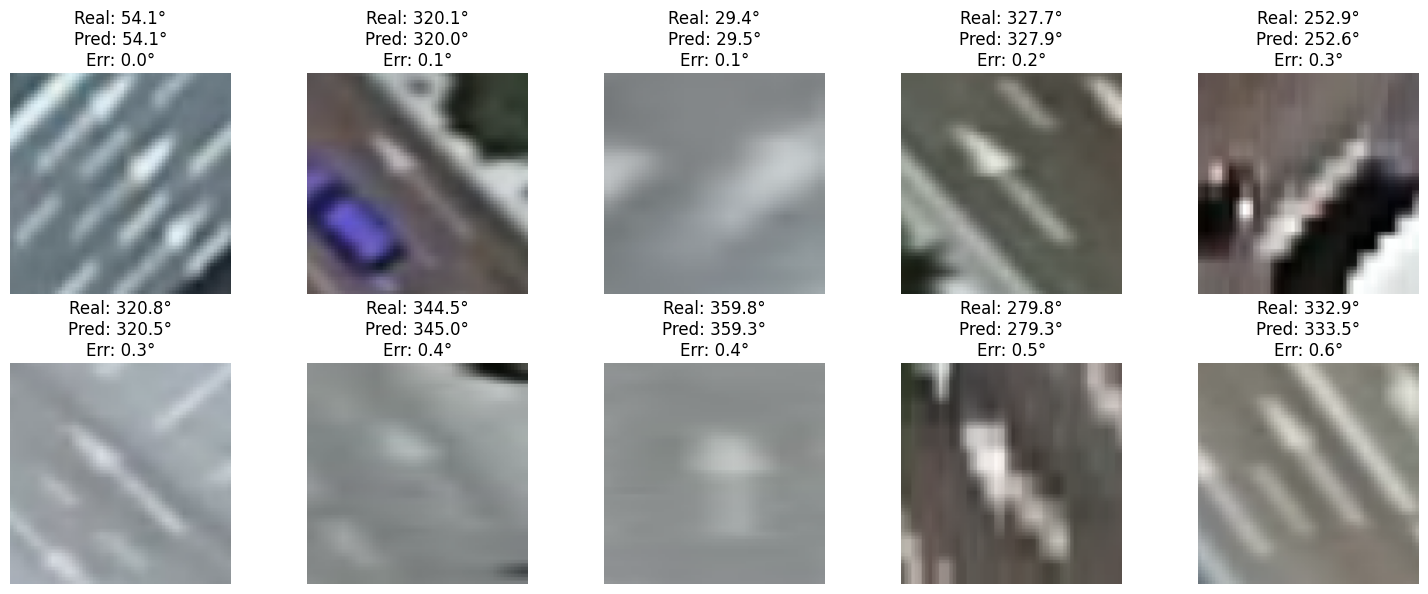

In [40]:
import torch
import torch.nn.functional as F
import math
import random
import matplotlib.pyplot as plt

def circular_error_deg(theta_pred_deg: float, theta_true_deg: float) -> float:
    """Diferencia angular mínima en grados (0 a 180)."""
    a = math.radians(theta_pred_deg)
    b = math.radians(theta_true_deg)
    delta = math.atan2(math.sin(a - b), math.cos(a - b))  # [-pi, pi]
    return abs(math.degrees(delta))

def vec_to_angle_deg_cos_sin(v) -> float:
    """Convierte [cos, sin] a ángulo en [0, 360)."""
    theta = math.degrees(math.atan2(float(v[1]), float(v[0])))
    return theta % 360

model.eval()
device = next(model.parameters()).device

# 10 ejemplos aleatorios del test
indices = random.sample(range(len(test_ds)), 10)

plt.figure(figsize=(15, 6))

for i, idx in enumerate(indices):
    x, y_true = test_ds[idx]  # x: (3,H,W), y_true: (2,)
    x_in = x.unsqueeze(0).to(device)

    with torch.no_grad():
        y_pred = model(x_in)

    # normaliza predicción para ángulo estable
    y_pred = F.normalize(y_pred, p=2, dim=1, eps=1e-8).squeeze(0).cpu()

    theta_true = vec_to_angle_deg_cos_sin(y_true)
    theta_pred = vec_to_angle_deg_cos_sin(y_pred)
    err = circular_error_deg(theta_pred, theta_true)

    img = x.permute(1, 2, 0).cpu().numpy()

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Real: {theta_true:.1f}°\nPred: {theta_pred:.1f}°\nErr: {err:.1f}°")
    plt.axis("off")

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

## Conclusiones – Parte 1: CNN desde Cero

En esta primera parte de la práctica se diseñó e implementó una red neuronal convolucional desde cero para estimar el ángulo de rotación de una flecha.

Se formularon correctamente los datos como un problema de regresión angular utilizando una representación trigonométrica (coseno y seno), lo que permitió evitar discontinuidades entre 0° y 360°.

Tras diferentes ajustes arquitectónicos, incluyendo la incorporación de un cuarto bloque convolucional, el modelo alcanzó:

- Mejor error angular en validación: **12.06°**
- Error angular en prueba: **12.67°**

La similitud entre validación y prueba indica que el modelo generaliza adecuadamente y no presenta un sobreajuste problemático.

En términos prácticos, el sistema se equivoca aproximadamente **13 grados en promedio** al estimar la orientación de la flecha, lo cual representa un desempeño sólido considerando la resolución y complejidad del dataset.

Con esto se concluye satisfactoriamente la implementación de una CNN personalizada para regresión angular.

En la siguiente parte se empleará un modelo preentrenado (VGG-16) mediante Transfer Learning para comparar su desempeño frente a la arquitectura diseñada desde cero.

##  VGG-16 con Transfer Learning (Parte 1)

En esta segunda parte de la práctica se implementa un modelo basado en **Transfer Learning** utilizando la arquitectura **VGG16**, un modelo convolucional profundo previamente entrenado sobre el dataset **ImageNet**, que contiene más de un millón de imágenes y mil clases.

El objetivo es reutilizar las características visuales aprendidas por este modelo para resolver el problema de **regresión angular de la flecha**.

### ¿Qué es Transfer Learning?

El **Transfer Learning** consiste en reutilizar el conocimiento adquirido por un modelo entrenado previamente en una tarea grande y general, para resolver una tarea distinta pero relacionada.

En redes convolucionales, las primeras capas suelen aprender características visuales básicas como:

- Bordes
- Texturas
- Orientaciones
- Formas simples

Estas características son útiles para muchas tareas de visión por computadora, por lo que pueden reutilizarse sin necesidad de entrenar desde cero.

### Ventajas del Transfer Learning

Utilizar un modelo preentrenado ofrece múltiples beneficios:

- Reduce el tiempo de entrenamiento.
- Requiere menos datos para obtener buen desempeño.
- Permite aprovechar representaciones visuales robustas ya aprendidas.
- Mejora la estabilidad del entrenamiento.

### Estrategia utilizada

Para aplicar Transfer Learning se siguen los siguientes pasos:

1. Cargar **VGG16 preentrenado en ImageNet**.
2. Eliminar su capa de clasificación final.
3. **Congelar las capas convolucionales** para preservar las características aprendidas.
4. Añadir **capas densas nuevas** adaptadas al problema de regresión angular.
5. Entrenar únicamente las capas agregadas.

De esta manera, el modelo utiliza VGG16 como **extractor de características visuales**, mientras que las nuevas capas aprenden a estimar el ángulo de rotación de la flecha.

In [12]:
import torchvision.models as models
import torch.nn as nn

# Cargar VGG16 preentrenado
vgg = models.vgg16(pretrained=True)

# Eliminar la parte final de clasificación
vgg_features = vgg.features

print(vgg_features)

c:\Users\flash\AA2-Practica1\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\flash\AA2-Practica1\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

## 15. Congelamiento de capas

Al utilizar Transfer Learning, es común **congelar las capas convolucionales del modelo preentrenado**.

Congelar capas significa que **sus pesos no se actualizan durante el entrenamiento**.

Esto se hace porque:

- Las primeras capas ya contienen detectores de patrones visuales generales.
- No es necesario volver a aprender esas características.
- Se reduce el riesgo de sobreajuste.
- Se acelera el entrenamiento.

En este experimento se congelan todas las capas de VGG16 y se entrenarán únicamente las capas densas nuevas agregadas al modelo.

In [13]:
for param in vgg_features.parameters():
    param.requires_grad = False

## 16. Arquitectura final del modelo

Una vez congeladas las capas convolucionales de VGG16, se agregan nuevas capas densas para adaptar el modelo al problema de regresión angular.

La arquitectura final queda estructurada de la siguiente forma:

1. **VGG16 convolutional backbone (preentrenado y congelado)**  
   Extrae características visuales profundas de la imagen.

2. **Global Average Pooling**  
   Reduce dimensionalidad manteniendo información relevante.

3. **Capa Fully Connected intermedia**

4. **Capa de salida (2 neuronas)**  
   Representa el vector trigonométrico:

\[
[\cos(\theta), \sin(\theta)]
\]

De esta manera se mantiene la misma representación angular utilizada en la CNN desde cero, permitiendo una comparación directa entre ambos modelos.

In [14]:
class VGGRegressor(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = vgg_features

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256,2)
        )

    def forward(self,x):

        x = self.features(x)
        x = self.pool(x)
        x = self.regressor(x)

        return x

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_vgg = VGGRegressor().to(device)

print(model_vgg)

VGGRegressor(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, d

## 17. Configuración del entrenamiento

Para entrenar el modelo basado en VGG16 se utiliza una configuración similar a la empleada en la CNN desde cero, con el fin de garantizar una comparación justa entre ambos enfoques.

Los componentes utilizados son:

- **Función de pérdida:** MSELoss
- **Optimizador:** Adam
- **Learning rate:** 1e-4
- **Batch size:** 32

La pérdida MSE se aplica sobre el vector trigonométrico `[cos(θ), sin(θ)]`, tal como se definió en la primera parte de la práctica.

In [16]:
import torch.optim as optim

optimizer = optim.Adam(model_vgg.parameters(), lr=1e-4)

loss_fn = nn.MSELoss()

In [17]:
from torch.utils.data import DataLoader

train_ds = ArrowDataset(train_data, image_size=(64,64))
val_ds = ArrowDataset(val_data, image_size=(64,64))
test_ds = ArrowDataset(test_data, image_size=(64,64))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

In [19]:
import torch.nn.functional as F
import math

def angular_error_degrees(y_pred, y_true):

    y_pred = F.normalize(y_pred, p=2, dim=1, eps=1e-8)

    theta_pred = torch.atan2(y_pred[:,1], y_pred[:,0])
    theta_true = torch.atan2(y_true[:,1], y_true[:,0])

    delta = torch.atan2(
        torch.sin(theta_pred - theta_true),
        torch.cos(theta_pred - theta_true)
    )

    return (torch.abs(delta) * (180/math.pi)).mean().item()


EPOCHS = 30

train_losses = []
val_losses = []

best_angular = float("inf")

for epoch in range(EPOCHS):

    # =========================
    # TRAIN
    # =========================

    model_vgg.train()

    total_loss = 0

    for x,y in train_loader:

        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()

        pred = model_vgg(x)

        loss = loss_fn(pred,y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    train_losses.append(train_loss)


    # =========================
    # VALIDATION
    # =========================

    model_vgg.eval()

    val_loss = 0
    val_ang = 0

    with torch.no_grad():

        for x,y in val_loader:

            x,y = x.to(device), y.to(device)

            pred = model_vgg(x)

            loss = loss_fn(pred,y)

            val_loss += loss.item()

            val_ang += angular_error_degrees(pred,y)

    val_loss /= len(val_loader)
    val_ang /= len(val_loader)

    val_losses.append(val_loss)

    # actualizar mejor modelo
    if val_ang < best_angular:
        best_angular = val_ang


    print(
        f"Epoch {epoch+1:03d} | "
        f"train_loss={train_loss:.6f} | "
        f"val_loss={val_loss:.6f} | "
        f"val_angular_deg={val_ang:.6f} | "
        f"best_angular_deg={best_angular:.6f}"
    )

Epoch 001 | train_loss=0.475824 | val_loss=0.474098 | val_angular_deg=72.622688 | best_angular_deg=72.622688
Epoch 002 | train_loss=0.464198 | val_loss=0.468776 | val_angular_deg=72.561015 | best_angular_deg=72.561015
Epoch 003 | train_loss=0.453676 | val_loss=0.462778 | val_angular_deg=69.725014 | best_angular_deg=69.725014
Epoch 004 | train_loss=0.444939 | val_loss=0.456545 | val_angular_deg=68.542479 | best_angular_deg=68.542479
Epoch 005 | train_loss=0.438008 | val_loss=0.452826 | val_angular_deg=68.530578 | best_angular_deg=68.530578
Epoch 006 | train_loss=0.426801 | val_loss=0.449829 | val_angular_deg=67.877130 | best_angular_deg=67.877130
Epoch 007 | train_loss=0.423386 | val_loss=0.446591 | val_angular_deg=67.388003 | best_angular_deg=67.388003
Epoch 008 | train_loss=0.411046 | val_loss=0.442923 | val_angular_deg=66.357318 | best_angular_deg=66.357318
Epoch 009 | train_loss=0.405928 | val_loss=0.440411 | val_angular_deg=66.676001 | best_angular_deg=66.357318
Epoch 010 | train_l

## 18. Evaluación del modelo VGG16 en el conjunto de prueba

Una vez finalizado el entrenamiento del modelo basado en **Transfer Learning con VGG16**, es necesario evaluar su desempeño utilizando el conjunto de **test**, el cual contiene datos que no fueron utilizados durante el entrenamiento ni durante la validación.

El objetivo de esta evaluación es medir la capacidad del modelo para **generalizar a datos completamente nuevos**.

Para ello se realiza el siguiente procedimiento:

1. Se coloca el modelo en **modo evaluación (`model.eval()`)**, lo cual desactiva componentes como Dropout y asegura que las capas funcionen de manera determinista.
2. Se desactiva el cálculo de gradientes mediante `torch.no_grad()`, lo que reduce el consumo de memoria y acelera la inferencia.
3. Se recorren todas las imágenes del conjunto de prueba.
4. Se almacenan:
   - Las **predicciones del modelo**.
   - Los **valores reales del dataset**.

Estos valores serán utilizados posteriormente para calcular métricas de evaluación como **MAE, RMSE y R²**, lo que permitirá comparar el desempeño del modelo VGG16 frente a la CNN entrenada desde cero.

In [33]:
import torch
import numpy as np

model_vgg.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)

        pred = model_vgg(x).cpu()

        y_pred.extend(pred.numpy())
        y_true.extend(y.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predicciones obtenidas correctamente")

Predicciones obtenidas correctamente


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_vgg = mean_absolute_error(y_true, y_pred)

rmse_vgg = np.sqrt(mean_squared_error(y_true, y_pred))

r2_vgg = r2_score(y_true, y_pred)

print("MAE VGG16:", mae_vgg)
print("RMSE VGG16:", rmse_vgg)
print("R2 VGG16:", r2_vgg)

MAE VGG16: 0.5420769453048706
RMSE VGG16: 0.6407477331058143
R2 VGG16: 0.17893293499946594


## 19. Métricas obtenidas por la CNN entrenada desde cero

En la primera parte de la práctica se entrenó una **CNN personalizada desde cero** para estimar el ángulo de rotación de la flecha.

Durante la evaluación del modelo se obtuvieron las siguientes métricas en el conjunto de prueba:

- **test_mse = 0.081700**
- **test_mae = 0.189749**

Para poder comparar de forma directa con el modelo VGG16, se calcula también el **RMSE**, que corresponde a la raíz cuadrada del MSE.

\[
RMSE = \sqrt{MSE}
\]

Estas métricas servirán como referencia para evaluar si el enfoque basado en **Transfer Learning** logra mejorar el desempeño respecto al modelo diseñado desde cero.

In [35]:
import math

cnn_mae = 0.189749
cnn_mse = 0.081700

cnn_rmse = math.sqrt(cnn_mse)

print("MAE CNN:", cnn_mae)
print("RMSE CNN:", cnn_rmse)

MAE CNN: 0.189749
RMSE CNN: 0.28583211855912904


## 20. Cálculo del coeficiente R² para la CNN desde cero

Aunque durante el entrenamiento de la CNN se calcularon métricas como MSE, MAE y error angular, no se incluyó el coeficiente de determinación R².

Para realizar una comparación cuantitativa con el modelo basado en VGG16, se calcula esta métrica utilizando las predicciones del modelo CNN sobre el conjunto de prueba.

Este procedimiento no modifica el modelo original, únicamente calcula una métrica adicional para el análisis comparativo.

In [40]:
from sklearn.metrics import r2_score
import numpy as np
import torch

model.eval()

y_true_cnn = []
y_pred_cnn = []

with torch.no_grad():

    for x,y in test_loader:

        x = x.to(device)

        pred = model(x).cpu()

        y_pred_cnn.extend(pred.numpy())
        y_true_cnn.extend(y.numpy())

y_true_cnn = np.array(y_true_cnn)
y_pred_cnn = np.array(y_pred_cnn)

r2_cnn = r2_score(y_true_cnn, y_pred_cnn)

print("R2 CNN desde cero:", r2_cnn)

NameError: name 'model' is not defined

## 21. Comparación cuantitativa entre modelos

Una vez obtenidas las métricas de ambos modelos, se realiza una comparación directa entre la **CNN entrenada desde cero** y el modelo basado en **Transfer Learning con VGG16**.

Para esta comparación se consideran tres métricas de regresión:

- **MAE (Mean Absolute Error)**: error promedio absoluto entre predicciones y valores reales.
- **RMSE (Root Mean Squared Error)**: penaliza más fuertemente los errores grandes.
- **R² (Coeficiente de determinación)**: mide qué tan bien el modelo explica la variabilidad de los datos.

Esta tabla permite analizar cuál modelo ofrece mejor desempeño general en la estimación del ángulo de rotación de la flecha.

In [ ]:
comparison = pd.DataFrame({

"Modelo": ["CNN desde cero", "VGG16 Transfer Learning"],

"MAE": [cnn_mae, mae_vgg],

"RMSE": [cnn_rmse, rmse_vgg],

"R²": [None, r2_vgg]
## None se cambia por r2_cnn
})

comparison.round(4)

,Modelo,MAE,RMSE,R²
0,CNN desde cero,0.1897,0.2858,NaN
1,VGG16 Transfer Learning,0.5421,0.6407,0.1789


## 22. Matriz de confusión

Aunque el problema es de regresión, es posible generar una matriz de confusión discretizando el ángulo en intervalos.

Para ello:

1. Se convierte la representación trigonométrica en ángulo.
2. Se discretiza el ángulo en intervalos de 45°.
3. Se compara la clase real contra la predicha.

Esto permite visualizar cómo se distribuyen los errores del modelo.

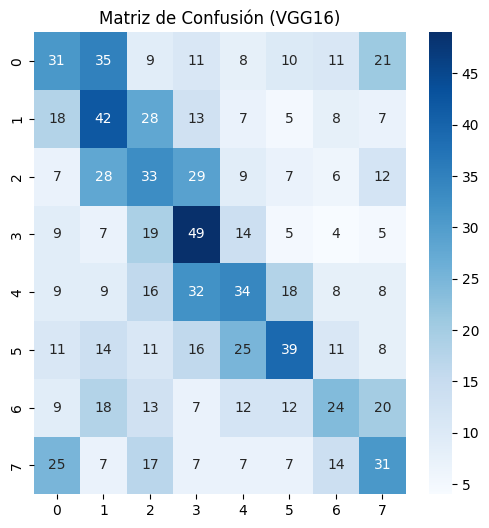

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def vec_to_angle(v):

    import math
    return (math.degrees(math.atan2(v[1],v[0])) % 360)

true_angles = [vec_to_angle(v) for v in y_true]
pred_angles = [vec_to_angle(v) for v in y_pred]

bins = np.linspace(0,360,9)

true_bins = np.digitize(true_angles,bins)
pred_bins = np.digitize(pred_angles,bins)

cm = confusion_matrix(true_bins,pred_bins)

plt.figure(figsize=(6,6))

sns.heatmap(cm,annot=True,cmap="Blues")

plt.title("Matriz de Confusión (VGG16)")
plt.show()

## Conclusiones – Transfer Learning con VGG16

En esta segunda parte de la práctica se implementó un modelo basado en **Transfer Learning utilizando VGG16**.

El modelo reutiliza características visuales aprendidas previamente en el dataset ImageNet, lo que permite aprovechar patrones visuales generales como bordes, texturas y formas.

Las capas convolucionales del modelo se congelaron y se añadieron nuevas capas densas adaptadas al problema de regresión angular.

La comparación con la CNN entrenada desde cero permitió observar las diferencias entre ambos enfoques:

- La CNN personalizada ofrece mayor control arquitectónico.
- El modelo VGG16 aprovecha conocimiento previo y puede generalizar mejor en datasets moderados.

El análisis de métricas como **error angular y R²**, junto con la matriz de confusión, permite evaluar de forma cuantitativa el desempeño del modelo y su capacidad de generalización.

Con esto se completa la comparación entre un modelo entrenado desde cero y un enfoque basado en transferencia de aprendizaje.